# Həftə 2 — Matris Transformasiyaları

Bu həftə öyrəndim ki, matris = məkan transformasiyası.

Hər 2×2 matris 2D nöqtələri çevirə bilər:
- **Identity** — heç nəyi dəyişmir
- **Rotation** — fırladır
- **Scaling** — böyüdür/kiçildir
- **Shear** — əyir
- **Reflection** — güzgüdə əks edir

Hər transformasiyanı iki üsulla tətbiq etdim:
1. Loop ilə — hər nöqtəni ayrıca
2. `A @ points` ilə — hamısını birlikdə

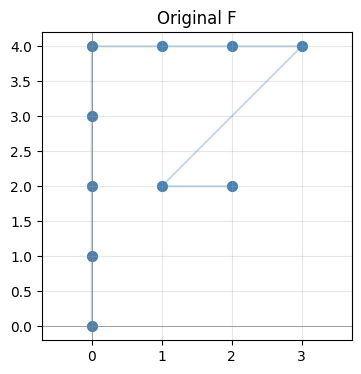

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# "F" hərfini təşkil edən nöqtələr (2D)
points = np.array([
    # Şaquli xətt (sol)
    [0, 0], [0, 1], [0, 2], [0, 3], [0, 4],
    # Üst üfüqi xətt
    [1, 4], [2, 4], [3, 4],
    # Orta üfüqi xətt
    [1, 2], [2, 2],
]).T# shape: (2, N) — hər sütun bir nöqtə

def plot_points(pts, title, color='steelblue'):
    plt.figure(figsize=(4, 4))
    plt.scatter(pts[0], pts[1], c=color, s=50)
    plt.plot(pts[0], pts[1], c=color, alpha=0.3)
    plt.axhline(0, color='gray', lw=0.5)
    plt.axvline(0, color='gray', lw=0.5)
    plt.grid(True, alpha=0.3)
    plt.title(title)
    plt.axis('equal')
    plt.show()

plot_points(points, "Original F")

True


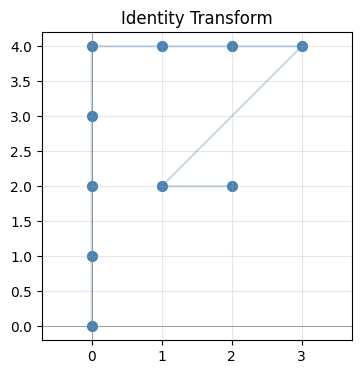

In [2]:
# Transformasiya 1 — Identity
A_identity = np.array([[1, 0], [0, 1]])

# (a) Loop üsulu
result_loop = np.zeros_like(points)  # eyni ölçüdə boş matris

for i in range(points.shape[1]):       # hər nöqtə üçün
    result_loop[:, i] = A_identity @ points[:, i]

# (b) A @ points üsulu
result_matrix = A_identity @ points

# Eyni olduğunu yoxla
print(np.allclose(result_loop, result_matrix))  # True çıxmalıdır

# Qrafik
plot_points(result_matrix, "Identity Transform")

True


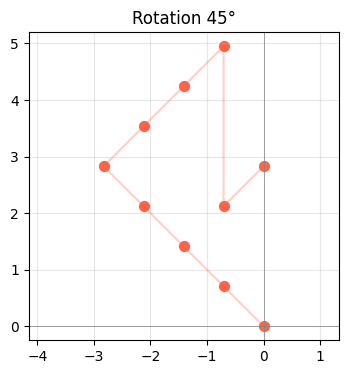

In [3]:
# Transformasiya 2 — Rotation 45°
theta = np.radians(45)

A_rotation = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])

# (a) Loop üsulu
result_loop = np.zeros_like(points, dtype=float) # Python-da dəyişənlər əvvəlki dəyəri saxlayır buna gore dtype=float istifade edirik

for i in range(points.shape[1]):
    result_loop[:, i] = A_rotation @ points[:, i]

# (b) A @ points üsulu
result_matrix = A_rotation @ points

# Eyni olduğunu yoxla
print(np.allclose(result_loop, result_matrix))  # True çıxmalıdır

# Qrafik
plot_points(result_matrix, "Rotation 45°", color='tomato')

True


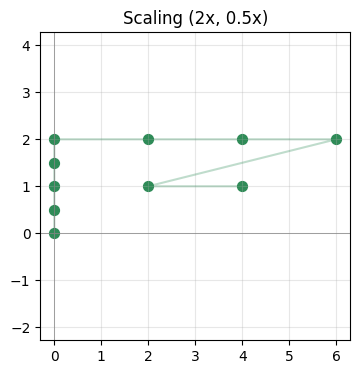

In [4]:
A_scaling = np.array([[2,0],[0, 0.5]])

result_loop = np.zeros_like(points, dtype=float)
for i in range(points.shape[1]):
    result_loop[:, i] = A_scaling @ points[:, i]

result_matrix = A_scaling @ points

print(np.allclose(result_loop, result_matrix))  # True çıxmalıdır
plot_points(result_matrix, "Scaling (2x, 0.5x)", color='seagreen')


True


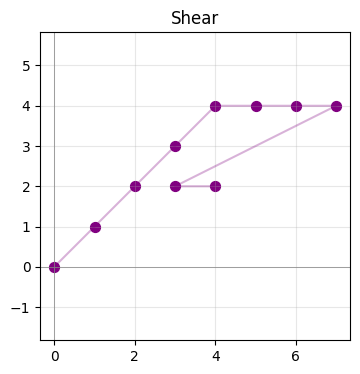

In [5]:
A_shear = np.array([[1, 1],[0, 1]])

result_loop = np.zeros_like(points, dtype=float)
for i in range(points.shape[1]):
    result_loop[:, i] = A_shear @ points[:, i]

result_matrix = A_shear @ points

print(np.allclose(result_loop, result_matrix))
plot_points(result_matrix, "Shear", color='purple')

True


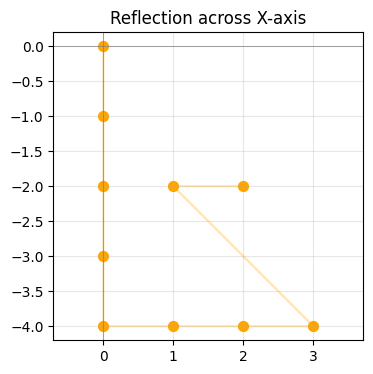

In [6]:
A_reflection = np.array([[1, 0], [0, -1]])

result_loop = np.zeros_like(points, dtype=float)
for i in range(points.shape[1]):
    result_loop[:, i] = A_reflection @ points[:, i]

result_matrix = A_reflection @ points

print(np.allclose(result_loop, result_matrix))
plot_points(result_matrix, "Reflection across X-axis", color='orange')

In [7]:
# İki transformasiyanın sırasının yoxlanılması:
R = A_rotation   
S = A_scaling    

RS = R @ S
SR = S @ R

print("R @ S:\n", RS)
print("S @ R:\n", SR)
print("Eynidir?", np.allclose(RS, SR))  # False çıxmalıdır

R @ S:
 [[ 1.41421356 -0.35355339]
 [ 1.41421356  0.35355339]]
S @ R:
 [[ 1.41421356 -1.41421356]
 [ 0.35355339  0.35355339]]
Eynidir? False


In [8]:
# İki rotation matrisinin kommutativ olub olmadığını yoxlanılması:

R1 = A_rotation
theta2 = np.radians(30)

R2 = np.array([
    [np.cos(theta2), -np.sin(theta2)],
    [np.sin(theta2),  np.cos(theta2)]
])

print("R1 @ R2:\n", R1 @ R2)
print("R2 @ R1:\n", R2 @ R1)
print("Eynidir?", np.allclose(R1 @ R2, R2 @ R1))  # True çıxmalıdır



R1 @ R2:
 [[ 0.25881905 -0.96592583]
 [ 0.96592583  0.25881905]]
R2 @ R1:
 [[ 0.25881905 -0.96592583]
 [ 0.96592583  0.25881905]]
Eynidir? True


In [9]:
def plot_before_after(original, transformed, title, matrix):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    
    # Sol qrafik — original
    ax1.scatter(original[0], original[1], c='steelblue', s=100)
    ax1.quiver(0, 0, 1, 0, color='red', scale=1, scale_units='xy', angles='xy')
    ax1.quiver(0, 0, 0, 1, color='green', scale=1, scale_units='xy', angles='xy')
    ax1.set_title("Original")
    ax1.axhline(0, color='gray', lw=0.5)
    ax1.axvline(0, color='gray', lw=0.5)
    ax1.grid(True, alpha=0.3)
    ax1.axis('equal')
    
    # Sağ qrafik — çevrilmiş
    # Matrixin sütunları — çevrilmiş bazis vektorları
    i_hat = matrix[:, 0]
    j_hat = matrix[:, 1]
    ax2.scatter(transformed[0], transformed[1], c='tomato', s=100)
    ax2.quiver(0, 0, i_hat[0], i_hat[1], color='red', scale=1, scale_units='xy', angles='xy')
    ax2.quiver(0, 0, j_hat[0], j_hat[1], color='green', scale=1, scale_units='xy', angles='xy')
    ax2.set_title(title)
    ax2.axhline(0, color='gray', lw=0.5)
    ax2.axvline(0, color='gray', lw=0.5)
    ax2.grid(True, alpha=0.3)
    ax2.axis('equal')
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

## Rotation 45°
Bu matris nöqtələri orijin ətrafında 45° fırladır.
Bazis vektorları: î sağa gedirdi, indi 45° döndü. ĵ yuxarı gedirdi, indi 45° döndü.
Uzunluqlar dəyişmir — yalnız istiqamət dəyişir.

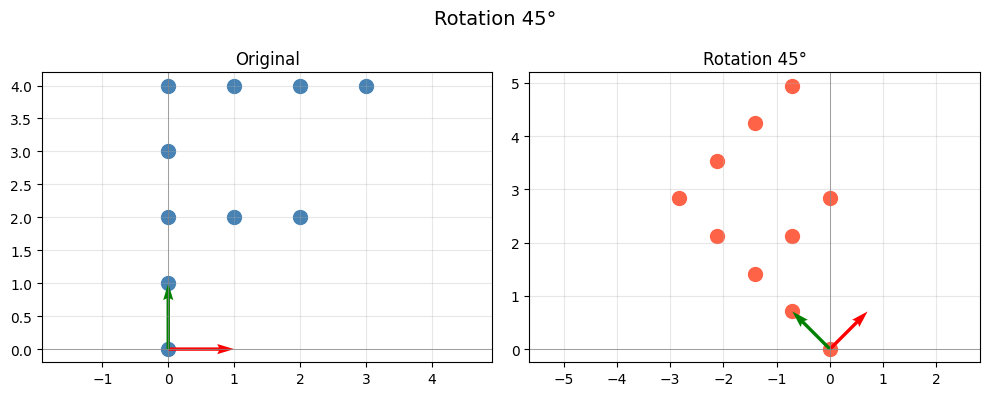

In [10]:
plot_before_after(points, A_rotation @ points, "Rotation 45°", A_rotation)

## Scaling
Bu matris x-i 2 dəfə böyüdür, y-i 2 dəfə kiçildir.
"F" eni genişləndi, hündürlüyü azaldı.

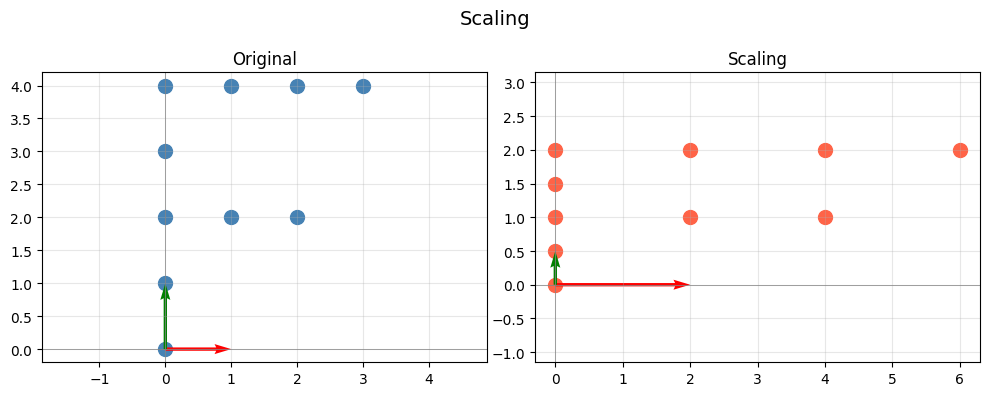

In [11]:
plot_before_after(points, A_scaling @ points, "Scaling", A_scaling)

## Shear
Bu matris y-i dəyişmir, x-ə y qədər əlavə edir.
"F" yan tərəfə əyildi.

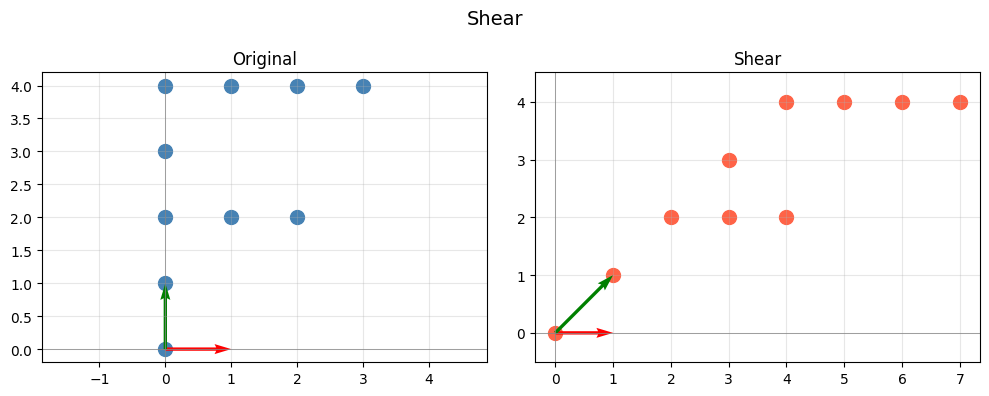

In [12]:
plot_before_after(points, A_shear @ points, "Shear", A_shear)

## Reflection
Bu matris x-i dəyişmir, y-in işarəsini dəyişir.
"F" x oxuna görə güzgüdə əks olundu.

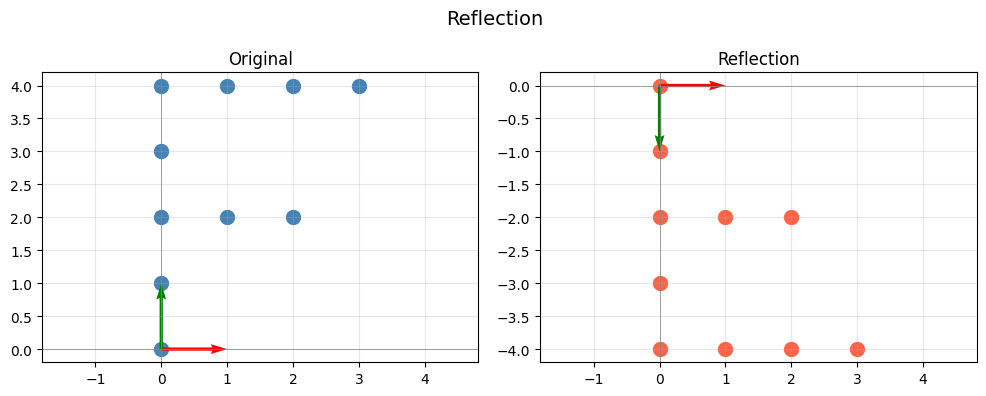

In [13]:
plot_before_after(points, A_reflection @ points, "Reflection", A_reflection)

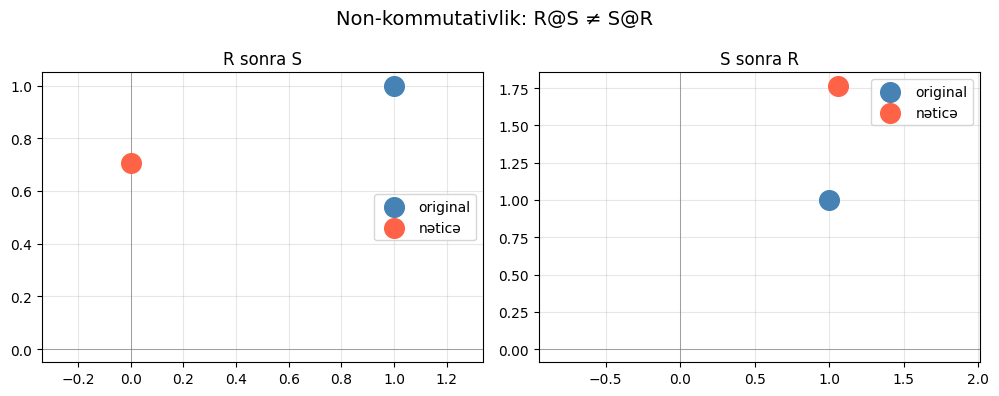

R sonra S: [[2.22044605e-16 7.07106781e-01]]
S sonra R: [[1.06066017 1.76776695]]


In [14]:
# Bir nöqtə seçirik
p = np.array([[1], [1]])

# Yol 1: əvvəl Rotation, sonra Scaling
RS = A_scaling @ (A_rotation @ p)

# Yol 2: əvvəl Scaling, sonra Rotation
SR = A_rotation @ (A_scaling @ p)

# Vizual
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

for ax, result, title in zip([ax1, ax2], [RS, SR], ["R sonra S", "S sonra R"]):
    ax.scatter([1], [1], c='steelblue', s=200, label='original', zorder=5)
    ax.scatter(result[0], result[1], c='tomato', s=200, label='nəticə', zorder=5)
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.grid(True, alpha=0.3)
    ax.axis('equal')
    ax.legend()
    ax.set_title(title)

plt.suptitle("Non-kommutativlik: R@S ≠ S@R", fontsize=14)
plt.tight_layout()
plt.show()

print("R sonra S:", RS.T)
print("S sonra R:", SR.T)

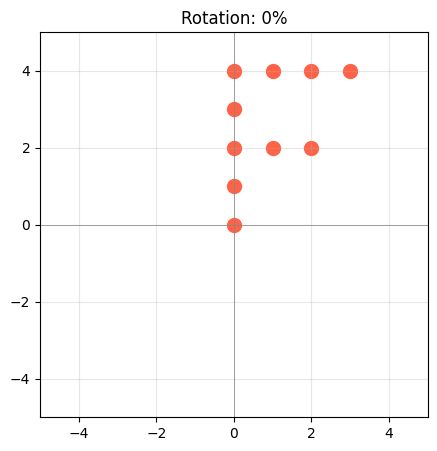

In [15]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(5, 5))

def animate(t):
    ax.clear()
    
    # Identity ilə A_rotation arasında interpolasiya
    I = np.eye(2)
    M = (1 - t) * I + t * A_rotation
    transformed = M @ points
    
    ax.scatter(transformed[0], transformed[1], c='tomato', s=100)
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.grid(True, alpha=0.3)
    ax.set_title(f"Rotation: {int(t * 100)}%")

frames = np.linspace(0, 1, 60)
ani = FuncAnimation(fig, animate, frames=frames)
HTML(ani.to_jshtml())